In [1]:
import seaborn as sns
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN, KMeansSMOTE, RandomOverSampler, SVMSMOTE, SMOTEN
from imblearn.combine import SMOTETomek, SMOTEENN

In [2]:
X, y = make_classification(n_samples=5000, n_features=2, n_informative=2,
                           n_redundant=0, n_repeated=0, n_classes=3,
                           n_clusters_per_class=1,
                           weights=[0.01, 0.05, 0.94],
                           class_sep=0.8, random_state=0)


Text(0.5, 0.98, 'Raw Data before SMOTE')

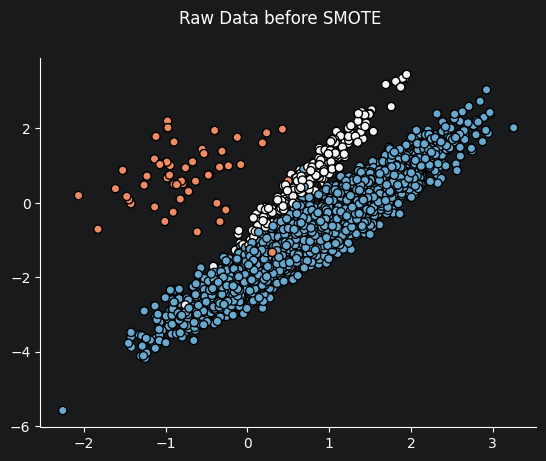

In [3]:
colors = ['#ef8a62' if v == 0 else '#f7f7f7' if v == 1 else '#67a9cf' for v in y]
kwarg_params = {'linewidth': 1, 'edgecolor': 'black'}
plt.scatter(X[:, 0], X[:, 1], c=colors, **kwarg_params)
sns.despine()
plt.suptitle("Raw Data before SMOTE")

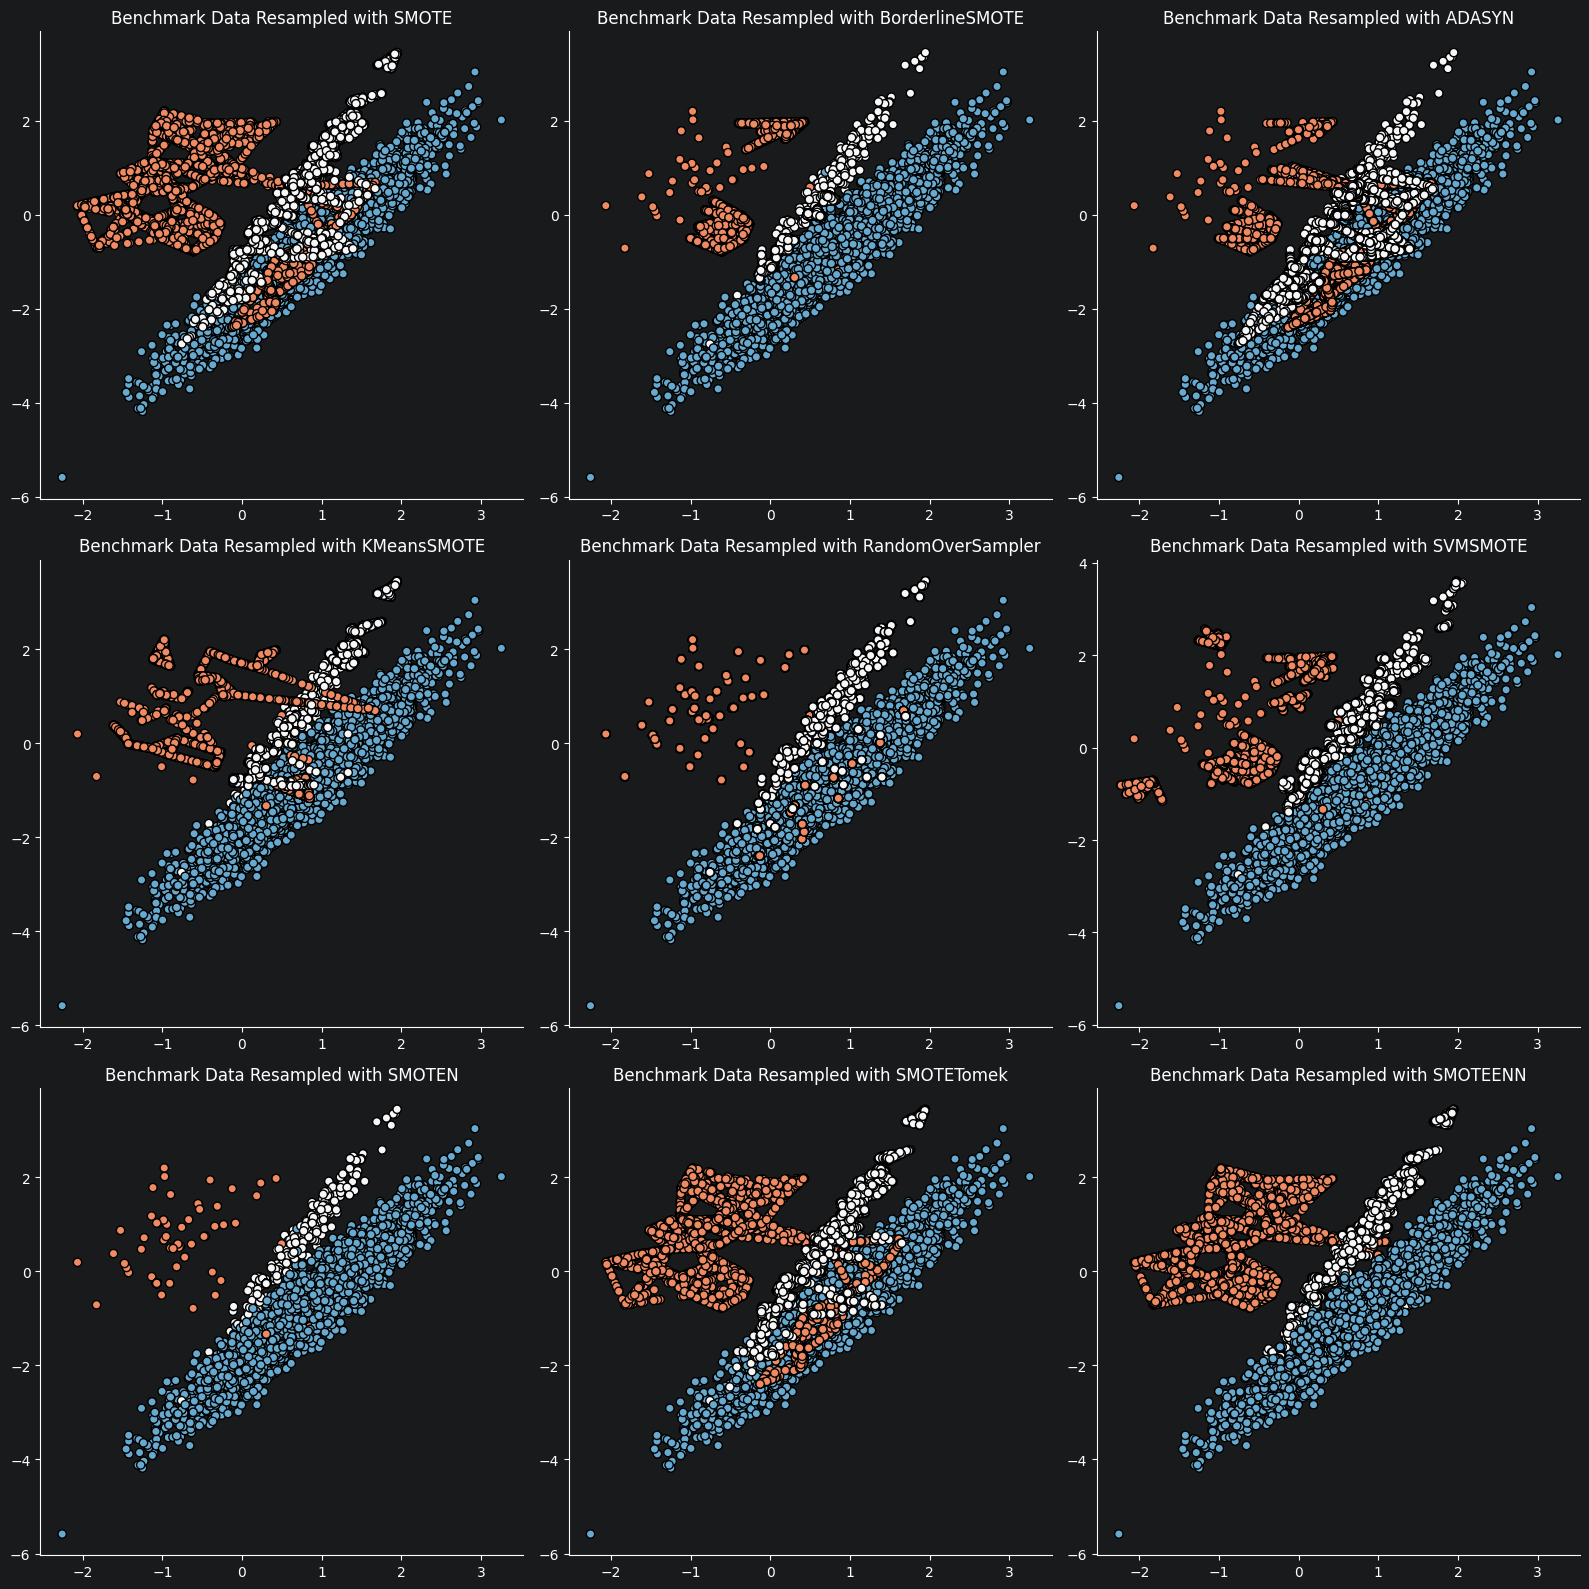

In [11]:
import math

strategies = [
    SMOTE(),
    BorderlineSMOTE(),
    ADASYN(),
    KMeansSMOTE(random_state=42, cluster_balance_threshold=0.01, k_neighbors=2),
    RandomOverSampler(),
    SVMSMOTE(),
    SMOTEN(),
    SMOTETomek(),
    SMOTEENN()
]

ncols = 3
n = len(strategies)
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 16))
axes = axes.ravel()  # flatten to 1D indexing

for idx, strategy in enumerate(strategies):
    ax = axes[idx]
    X_resampled, y_resampled = strategy.fit_resample(X, y)
    kwarg_params = {'linewidth': 1, 'edgecolor': 'black'}
    colors = ['#ef8a62' if v == 0 else '#f7f7f7' if v == 1 else '#67a9cf' for v in y_resampled]
    ax.scatter(X_resampled[:, 0], X_resampled[:, 1], c=colors, **kwarg_params)
    sns.despine()
    title = f"Benchmark Data Resampled with {strategy.__class__.__name__}"
    ax.set_title(title)

# turn off any unused axes (when n is not a multiple of ncols)
for j in range(n, nrows * ncols):
    axes[j].axis("off")

plt.tight_layout()
plt.show()